In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

In [3]:
from google.colab import files
uploaded = files.upload()

Saving letter-recognition.xlsx to letter-recognition.xlsx
Saving iris (1).xlsx to iris (1).xlsx


In [4]:
iris = pd.read_excel("iris (1).xlsx")
letter = pd.read_excel("letter-recognition.xlsx")

print(iris.head())
print(letter.head())

   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa
  letter  xbox  ybox  width  height  onpix  xbar  ybar  x2bar  y2bar  xybar  \
0      T     2     8      3       5      1     8    13      0      6      6   
1      I     5    12      3       7      2    10     5      5      4     13   
2      D     4    11      6       8      6    10     6      2      6     10   
3      N     7    11      6       6      3     5     9      4      6      4   
4      G     2     1      3       1      1     8     6      6      6      6   

   x2ybar  xy2bar  xedge  xedgey  yedge  yedgex  
0      10       8      0       8      0       8  
1       3  

Linear Kernel Accuracy: 1.0


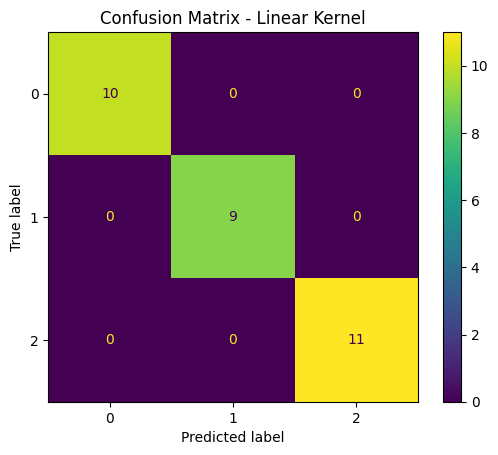

RBF Kernel Accuracy: 1.0


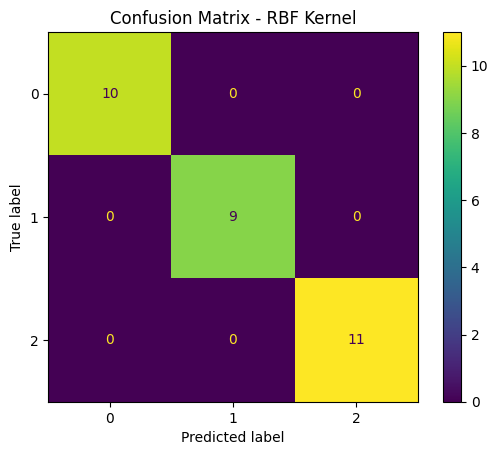

In [5]:
X = iris.iloc[:, :-1]
y = iris.iloc[:, -1]

le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Linear Kernel
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train, y_train)

y_pred_linear = svm_linear.predict(X_test)

print("Linear Kernel Accuracy:", accuracy_score(y_test, y_pred_linear))

cm = confusion_matrix(y_test, y_pred_linear)
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix - Linear Kernel")
plt.show()


# RBF Kernel
svm_rbf = SVC(kernel='rbf')
svm_rbf.fit(X_train, y_train)

y_pred_rbf = svm_rbf.predict(X_test)

print("RBF Kernel Accuracy:", accuracy_score(y_test, y_pred_rbf))

cm = confusion_matrix(y_test, y_pred_rbf)
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix - RBF Kernel")
plt.show()

Accuracy: 0.9305


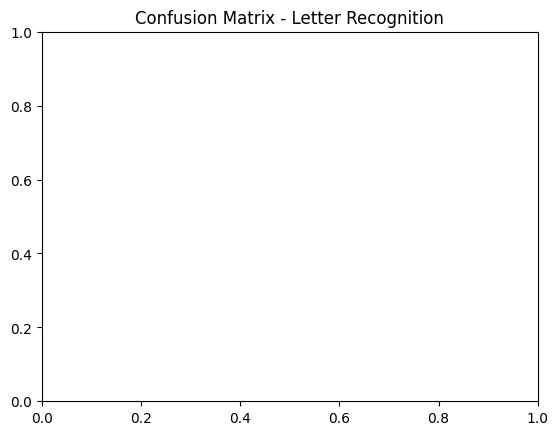

In [6]:
X = letter.iloc[:, 1:]
y = letter.iloc[:, 0]

le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

svm_model = SVC(kernel='rbf', probability=True)
svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm)
plt.title("Confusion Matrix - Letter Recognition")
plt.show()

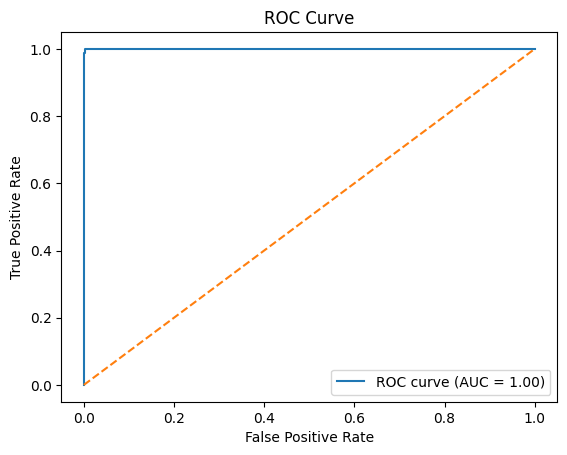

AUC Score: 0.99994074580123


In [7]:
y_test_bin = label_binarize(y_test, classes=np.unique(y))
y_score = svm_model.predict_proba(X_test)

fpr, tpr, _ = roc_curve(y_test_bin[:,0], y_score[:,0])
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="ROC curve (AUC = %0.2f)" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("AUC Score:", roc_auc)